# SENDAs Agreement 1 Update 2010-2024 (Prediction, step 2.6, external temporal validation, readmission)

<style type="text/css">
.showopt {
background-color: #004c93; color: #FFFFFF; width: 100px; height: 20px; text-align: center; vertical-align: middle !important; float: right; font-family: sans-serif; border-radius: 8px;
}
.showopt:hover {
background-color: #dfe4f2;
color: #004c93;
}
pre.plot {
background-color: white !important;
}
.tablelines table, .tablelines td, .tablelines th {
border: 1px solid black;
}
.centrado {
text-align: center;
}
.table.center {
margin-left:auto;
margin-right:auto;
}
/* https://vivekjaiskumar.medium.com/css-is-and-not-selector-17c942ec83f :is()*/
/* Applies to outputs that are not code other than R*/
pre {
overflow-x: auto !important;
}
pre code {
word-wrap: normal !important;
white-space: pre !important;
}
/*
pre:not(.sourceCode) {
white-space: nowrap !important;
}
*/
.sourceCode { /* Important gives precedence */
font-size: 10px !important;
line-height: 50% !important;
}
body{ /* Normal */
text-align: justify;
}
.superbigimage{
overflow-y:scroll;
height:350px;
white-space: nowrap;
overflow-x: auto;
width:100%;
}
.superbigimage img{
overflow-y: scroll;
overflow-x: hidden;
}
.message { color:#446C6E; font-family: monospace;font-size: 10px; line-height: 110%; font-weight: bold;}
div.blue { background-color:#e6f0ff; border-radius: 5px; padding: 5px; text-align: justify;}
div.red { background-color:#e6bab1; border-radius: 5px; padding: 5px; text-align: justify;}
.pandoc-table { /* Should add !important; but it seems no necessary */
margin-left:auto; /* To center */
margin-right:auto;
border-collapse: collapse;
table-layout: auto;
font-size: 11px;
overflow-y: auto;
max-height:450px !important;
white-space: nowrap;
overflow-x: auto;
width:450px;
}
.pandoc-table th {/* header */
text-align: center !important;
font-size: 10px;
padding: 0px;
}
.pandoc-table td {
text-align: left !important;
font-size: 9px;
padding: 0px;
}
.pandoc-table caption {
text-align: left !important;
font-size: 11px !important;
}
.center-table {
text-align: left !important;
font-size: 9px;
overflow-y:scroll;
height:450px;
overflow-x: scroll;
}
.controlly{
overflow-y:scroll;
height:350px;
overflow-x: scroll;
}
/*2025-03-07*/
.callout-warning,
.callout-error,
.callout-message {
  font-size: 0.7rem !important;  /* Adjust this value as needed */
}
.alert, .message {
    font-size: 0.7em !important;
}
.alert.alert-warning,
.alert.alert-danger,
.message {
    font-size: 0.7em !important;
}
</style>


<style>
#| label: css-format
h1 {
    color: var(--heading-color);
    font-size: 2rem;
    margin-bottom: 1vh;
}
p {
  font-size: 1.1rem;
  line-height: 1.6rem;
}
a {
  color: var(--primary-color);
  text-decoration: none;
  border-bottom: 3px solid transparent;
  font-weight: bold;
  &:hover, &:focus {
      border-bottom: 3px solid currentColor;
  }
}
section {
  margin: 0 auto;
}
.post-meta {
  font-size: 1rem;
  font-style: italic;
  display: block;
  margin-bottom: 4vh;
  color: var(--secondary-color);
}
nav {
  display: flex;
  justify-content: flex-end;
  padding: 20px 0;
}
/*slider switch css */
.theme-switch-wrapper {
  display: flex;
  align-items: center;
  
  em {
    margin-left: 10px;
    font-size: 1rem;
  }
}
.theme-switch {
  display: inline-block;
  height: 34px;
  position: relative;
  width: 60px;
}
.theme-switch input {
  display:none;
}
.slider {
  background-color: #ccc;
  bottom: 0;
  cursor: pointer;
  left: 0;
  position: absolute;
  right: 0;
  top: 0;
  transition: .4s;
}
.slider:before {
  background-color: #fff;
  bottom: 4px;
  content: "";
  height: 26px;
  left: 4px;
  position: absolute;
  transition: .4s;
  width: 26px;
}
input:checked + .slider {
  background-color: #66bb6a;
}
input:checked + .slider:before {
  transform: translateX(26px);
}
.slider.round {
  border-radius: 34px;
}
.slider.round:before {
  border-radius: 50%;
}
</style>


<style>
.scrollable-content {
  max-height: 350px;
  overflow-y: auto;
}
pre.scrollable-code {
  max-height: 350px;
  overflow-y: auto;
}
.superbigimage {
  overflow-x: scroll;
  white-space: nowrap;
}
.superbigimage img, 
.superbigimage svg {
  max-width: none;
  height: auto;
}
</style>
<br>

# Data Loading and Exploration

## Loading Packages and uniting databases

<div class="scrollable-content">


In [1]:
#| label: setup
#| results: "hold"
#renv falls back to copying rather than symlinking, which is evidently very slow in this configuration.
renv::settings$use.cache(FALSE)
#only use explicit dependencies (in DESCRIPTION)
renv::settings$snapshot.type("implicit")
#check if rstools is installed
if(Sys.info()["sysname"]=="Windows"){
try(installr::install.Rtools(check_r_update=F))
}
check_quarto_version <- function(required = "1.7.29", comparator = c("ge","gt","le","lt","eq")) {
  comparator <- match.arg(comparator)
  current <- package_version(paste(unlist(quarto::quarto_version()), collapse = "."))
  req     <- package_version(required)
  ok <- switch(comparator,
               ge = current >= req,
               gt = current >  req,
               le = current <= req,
               lt = current <  req,
               eq = current == req)
  if (!ok) {
    stop(sprintf("Quarto version check failed: need %s %s (installed: %s).",
                 comparator, required, current), call. = FALSE)
  }
  invisible(TRUE)
}
check_quarto_version("1.7.29", "ge") 
#change repository to CL
local({
  r <- getOption("repos")
  r["CRAN"] <- "https://cran.dcc.uchile.cl/"
  options(repos=r)
})
if(!require(pacman)){install.packages("pacman");require(pacman)}
if(!require(pak)){install.packages("pak");require(pak)}
pacman::p_unlock(lib.loc = .libPaths()) #para no tener problemas reinstalando paquetes
if(Sys.info()["sysname"]=="Windows"){
if (getRversion() != "4.4.1") { stop("Requires R version 4.4.1; Actual: ", getRversion()) }
}
#check docker
check_docker_running <- function() {
  # Try running 'docker info' to check if Docker is running
  system("docker info", intern = TRUE, ignore.stderr = TRUE)
}
if(Sys.info()["sysname"]=="Windows"){
  install_docker <- function() {
    # Open the Docker Desktop download page in the browser for installation
    browseURL("https://www.docker.com/products/docker-desktop")
  }
  # Main logic
  if (inherits(try(check_docker_running(), silent = TRUE), "try-error")) {
    liftr::install_docker()
  } else {
    message("Docker is running.")
  }
}
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#PACKAGES#######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
unlink("*_cache", recursive=T)
pak::pak_sitrep()
# pak::sysreqs_check_installed(unique(unlist(paks)))
#pak::lockfile_create(unique(unlist(paks)),  "dependencies_duplicates24.lock", dependencies=T)
#pak::lockfile_install("dependencies_duplicates24.lock")
#https://rdrr.io/cran/pak/man/faq.html
#pak::cache_delete()
library(tidytable)
library(ggplot2)
library(readr)
library(tableone)
library(survivalmodels)
#renv::install("patchwork@1.2.0")
library(rms)
library(survidm)
library(caret)
library(survival)
library(riskRegression)
library(prodlim)
library(caret)
library(ggplot2)
library(dplyr)
library(survex)
library(pec)
library(future)
library(future.apply)
library(parallel)
library(mice)
library(riskRegression)
library(tidyr)
library(doFuture)
library(vcd)
library(survAUC)
library(knitr)
if (!requireNamespace("ipeval", quietly = TRUE)) {
  renv::install("ipeval")
}
#flexsurv
#if(!require(compareCstat)){install.pacakges("compareCstat")}
# library(shapr)#https://norskregnesentral.github.io/shapr/
# library(SemiMarkov)#https://www.degruyterbrill.com/document/doi/10.1515/ijb-2020-0083/html?lang=en
# #https://www.jclinepi.com/article/S0895-4356(24)00142-2/fulltext
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 3. Activate polars code completion (safe to try even if it fails)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
#try(polars_code_completion_activate())
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 4. BPMN from GitHub (not on CRAN, so install via devtools if missing)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
if (!requireNamespace("bpmn", quietly = TRUE)) {
  devtools::install_github("bergant/bpmn")
}
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 5. PhantomJS Check (use webshot if PhantomJS is missing)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# if (!webshot::is_phantomjs_installed()) {
#   webshot::install_phantomjs()
# }
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#FUNCTIONS######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
# NO MORE DEBUGS
options(error = NULL)        # si antes tenías options(error = recover) o browser)
options(browserNLdisabled = FALSE)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#NAs are replaced with "" in knitr kable
options(knitr.kable.NA = '')
pander::panderOptions('big.mark', ',')
pander::panderOptions('decimal.mark', '.')

#To produce line breaks in messages and warnings
knitr::knit_hooks$set(
   error = function(x, options) {
     paste('\n\n<div class="alert alert-danger" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Error', '**Error**', x)),
           '</div>', sep = '\n')
   },
   warning = function(x, options) {
     paste('\n\n<div class="alert alert-warning" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Warning:', '**Warning**', x)),
           '</div>', sep = '\n')
   },
   message = function(x, options) {
     paste('<div class="message" style="font-size: small !important;">',
           gsub('##', '\n', x),
           '</div>', sep = '\n')
   }
)

tnr<- "Times New Roman" 

options(scipen=2) #display numbers rather scientific number

# ── Helpers ────────────────────────────────────────────────────────────
mode_pick_int <- function(x){
  x <- x[!is.na(x)]
  if(length(x)==0) return(NA_integer_)
  tx <- sort(table(x), decreasing = TRUE)
  as.integer(names(tx)[1L])
}
subkey_to_label <- function(x){
  y <- gsub("_"," ", tolower(x))
  y <- gsub("amphetamine type stimulants","amphetamine-type stimulants", y)
  y <- gsub("tranquilizers hypnotics","tranquilizers/hypnotics", y)
  y
}

#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
find_latest_file <- function(project_root, prefix) {
  # Get all files matching the pattern
  pattern <- paste0(prefix, "_\\d{8}_\\d{4}\\.csv$")
  files <- list.files(
    path = project_root,
    pattern = pattern,
    full.names = TRUE
  )
  if (length(files) == 0) {
    stop(paste("No files found matching pattern:", pattern))
  }
  # Extract timestamps from filenames (format: YYYYMMDD_HHMM)
  extract_timestamp <- function(filename) {
    matches <- regmatches(
      basename(filename),
      gregexpr("\\d{8}_\\d{4}", basename(filename))
    )
    if (length(matches[[1]]) == 0) {
      return(NA)
    }
    timestamp_str <- matches[[1]][length(matches[[1]])]
    return(timestamp_str)
  }
  timestamps <- sapply(files, extract_timestamp)
  # Remove any files where timestamp extraction failed
  valid_idx <- !is.na(timestamps)
  files <- files[valid_idx]
  timestamps <- timestamps[valid_idx]
  if (length(files) == 0) {
    stop("No valid timestamps found in filenames")
  }
  # Sort by timestamp (descending) and return the latest
  latest_idx <- order(timestamps, decreasing = TRUE)[1]
  return(files[latest_idx])
}

Installing package into ‘C:/Users/andre/AppData/Local/R/win-library/4.4’
(as ‘lib’ is unspecified)


trying URL 'https://cran.rstudio.com/bin/windows/contrib/4.4/pkgbuild_1.4.8.zip'
Content type 'application/zip' length 211084 bytes (206 KB)
downloaded 206 KB



package ‘pkgbuild’ successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\andre\AppData\Local\Temp\RtmpK4zbg7\downloaded_packages
Loading required package: pkgbuild
No need to install Rtools - You've got the relevant version of Rtools installed


Warning message:
package ‘pkgbuild’ was built under R version 4.4.3 


Loading required package: pacman


...

Warning message:
package ‘pec’ was built under R version 4.4.3 



Attaching package: ‘future’

The following object is masked from ‘package:survival’:

    cluster

The following object is masked from ‘package:caret’:

    cluster



Warning message:
package ‘future.apply’ was built under R version 4.4.3 


Registered S3 method overwritten by 'broom':
  method        from          
  nobs.multinom riskRegression

Attaching package: ‘mice’

The following objects are masked from ‘package:tidytable’:

    complete, filter

The following object is masked from ‘package:stats’:

    filter

The following objects are masked from ‘package:base’:

    cbind, rbind


Attaching package: ‘tidyr’

The following objects are masked from ‘package:tidytable’:

    complete, crossing, drop_na, expand, expand_grid, extract, fill, nest, nesting, pivot_longer, pivot_wider, replace_na,
    separate, separate_longer_delim, separate_rows, separate_wider_delim, separate_wider_regex, tribble, uncount, unite, unnest,
    unnest_longer, unnest_wider

Loading required package: foreach
Loading required package: grid


Warning message:
package ‘survAUC’ was built under R version 4.4.3 
Warning message:
package ‘knitr’ was built under R version 4.4.3 


In [2]:
#| label: define-project-root-and-paths
root <- here::here()
project_root <- gsub("/cons$", "", root)
data_out <- file.path(project_root, "data", "20241015_out")
figs_out <- file.path(root, "_figs")
out_dir  <- file.path(project_root, "cons", "_out")

In [3]:
#| label: set-global-options
#| message: false

options(future.globals.maxSize = 10 * 1024^3)

In [4]:
project_root <- gsub("/cons$", "", getwd())

# External (temporal) validation: first SUD treatment readmission

The frozen readmission Cox model (development cohort 2010-2020, discharge clock; loaded from `data/20241015_out/msm_artifact_2026_06_20.rds`, transition `readmit_1_2`) is applied **without refitting** to an independent temporal cohort. Index episodes are the first qualifying SUD treatment (age 18 to 64) admitted between 2021-01-01 and 2024-12-31 for patients who did not contribute any qualifying episode to the development cohort (no patient overlap); first readmission to treatment is followed to the administrative censoring date 2025-05-28. We report Uno's C-index, the integrated Brier score (IBS) and calibration (predicted vs observed via Kaplan-Meier, death treated as censoring) with nonparametric bootstrap 95% CIs, and compare the covariate distribution against the development cohort using standardized mean differences (SMD).

All metric, dummify and calibration helpers are reused unchanged from the held-out validation engines (`val_holdout_02_build_sets.R`, `evaluate_dual_cox_python_style_boot.R`, `validate_holdout_metrics.R`); no development data are refit or rebuilt.

In [5]:
#| label: extval-source-engines
#| message: false
project_root <- gsub("/cons$", "", getwd())
source(file.path(project_root, "cons/_alt_scripts/extval_01_build_cohort.R"))
source(file.path(project_root, "cons/_alt_scripts/run_extval_readmit.R"))
source(file.path(project_root, "cons/_alt_scripts/extval_02_table1_smd.R"))

# External follow-up: admissions stop 2024-12-20, censoring 2025-05-28 (max ~52 months),
# so 48-60 month horizons are not supported; we report 3/6/12/36 months.
EVAL_TIMES <- c(3, 6, 12, 36)
CAL_TIMES  <- c(6, 12, 36)
B_BOOT     <- 1000L


## Cohort construction

In [6]:
#| label: extval-build-cohort
built <- build_extval_readmit_cohort(verbose = TRUE)
knitr::kable(built$flow, "markdown",
  caption = "External cohort construction: new patients, index admission 2021-2024, first readmission censored 2025-05-28")


Loading prev1y: g:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/251001_c1_1025_df_prev1y.rds 
0. INITIAL prev1y: cases=162,897, patients=121,299
   Development-cohort patients (qualifying 2010-2020) to exclude: 88,632
1. After excluding development patients: 32,667 patients remain; 28,491 have >=1 qualifying 2021-2024 episode
2. First qualifying episode per patient: 28,491
3. After dropping 'currently in': 26,361

=== EXTERNAL COHORT FLOW ===
                                       step      n
                                prev1y rows 162897
                            prev1y patients 121299
              development patients excluded  88632
                         patients remaining  32667
 patients with qualifying 2021-2024 episode  28491
       first qualifying episode per patient  28491
      after dropping 'currently in' (FINAL)  26361
                         readmission events   2521
                       readmission censored  23840




Table: External cohort construction: new patients, index admission 2021-2024, first readmission censored 2025-05-28

|step                                       |      n|
|:------------------------------------------|------:|
|prev1y rows                                | 162897|
|prev1y patients                            | 121299|
|development patients excluded              |  88632|
|patients remaining                         |  32667|
|patients with qualifying 2021-2024 episode |  28491|
|first qualifying episode per patient       |  28491|
|after dropping 'currently in' (FINAL)      |  26361|
|readmission events                         |   2521|
|readmission censored                       |  23840|

In [7]:
#| label: extval-prepare
#| message: false
ext_dat <- dummify_extval(built$nondum, complete_case = TRUE, verbose = TRUE)
fit_readmit <- load_frozen_readmit()
cat(sprintf("External analysis set: n = %d; readmission events = %d (%.1f%%)\n",
  nrow(ext_dat), sum(ext_dat$readmit_event), 100 * mean(ext_dat$readmit_event)))


Complete-case on readmission predictors: 26361 -> 25866 rows (dropped 495, 1.9%)
External analysis set: n = 25866; readmission events = 2486 (9.6%)


## Discrimination (Uno's C-index) and prediction error (IBS)

Uno's C-index (IPCW, `timewt = "n/G2"`) and the IPCW integrated Brier score, computed on the frozen linear predictor and survival curves; 95% CIs from nonparametric bootstrap of the external patients (model frozen, no refit).

In [8]:
#| label: extval-discrimination
#| message: false
ev_ext <- evaluate_extval_readmit(fit_readmit, ext_dat, eval_times = EVAL_TIMES)

# Parallel backend for the patient bootstrap (sequential worker startup avoids the
# 'workers failed to connect' timeout on Drive paths). The bootstrap is the slow step
# (per-replicate IPCW concordance + loess ICI); with B=1000 expect ~10-25 min. Set
# parallel = FALSE below for a single-core run, or lower B_BOOT for a quick check.
if (requireNamespace("future", quietly = TRUE) && !inherits(future::plan(), "multisession")) {
  options(parallelly.makeNodePSOCK.setup_strategy = "sequential")
  options(parallelly.makeNodePSOCK.connectTimeout = 600)
  future::plan(future::multisession, workers = min(8L, max(1L, parallelly::availableCores() %/% 2L)))
}
options(future.globals.maxSize = 10 * 1024^3)

boot_ext <- bootstrap_extval_readmit(fit_readmit, ext_dat, eval_times = EVAL_TIMES,
             cal_times = CAL_TIMES, B = B_BOOT, seed = 2125L, parallel = TRUE, verbose = TRUE)

fmt_ci <- function(metric, time, bkey, dig = 3) {
  e <- ev_ext$summary$Value[ev_ext$summary$Metric == metric & ev_ext$summary$Time == time]
  r <- boot_ext[boot_ext$metric == bkey, ]
  if (!length(e) || is.na(e)) return("\u2014")
  if (!nrow(r)) return(sprintf(paste0("%.", dig, "f"), e))
  sprintf(paste0("%.", dig, "f (%.", dig, "f, %.", dig, "f)"), e, r$lo[1], r$hi[1])
}
disc <- data.frame(
  Metric  = c(rep("Uno's C-index", 1 + length(EVAL_TIMES)), "IBS (global)"),
  Horizon = c("Global", as.character(EVAL_TIMES), "Global"),
  `Estimate (95% CI)` = c(
    fmt_ci("Uno's C-Index", "Global", "c_global"),
    sapply(EVAL_TIMES, function(h) fmt_ci("Uno's C-Index", as.character(h), paste0("c_", h))),
    fmt_ci("IBS", "Global", "ibs_global")),
  check.names = FALSE, stringsAsFactors = FALSE)
knitr::kable(disc, "markdown", caption = "External validation: Uno's C-index and IBS (bootstrap 95% CI; model frozen, no refit)")




Table: External validation: Uno's C-index and IBS (bootstrap 95% CI; model frozen, no refit)

|Metric        |Horizon |Estimate (95% CI)    |
|:-------------|:-------|:--------------------|
|Uno's C-index |Global  |0.591 (0.578, 0.603) |
|Uno's C-index |3       |0.577 (0.557, 0.599) |
|Uno's C-index |6       |0.594 (0.578, 0.610) |
|Uno's C-index |12      |0.590 (0.578, 0.603) |
|Uno's C-index |36      |0.589 (0.577, 0.600) |
|IBS (global)  |Global  |0.206 (0.191, 0.214) |

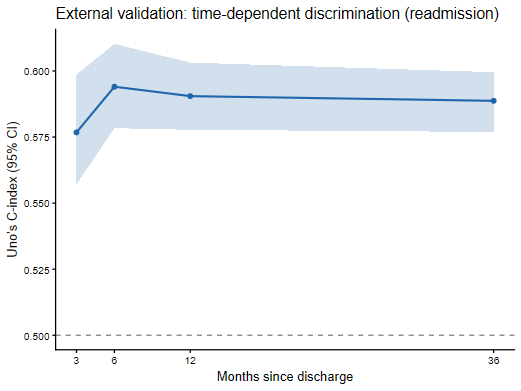

In [9]:
#| label: extval-cindex-plot
#| fig-width: 7
#| fig-height: 4
cidx_df <- do.call(rbind, lapply(EVAL_TIMES, function(h) {
  e <- ev_ext$summary$Value[ev_ext$summary$Metric == "Uno's C-Index" & ev_ext$summary$Time == as.character(h)]
  r <- boot_ext[boot_ext$metric == paste0("c_", h), ]
  data.frame(Horizon = h, C = e, lo = if (nrow(r)) r$lo[1] else NA, hi = if (nrow(r)) r$hi[1] else NA)
}))
ggplot2::ggplot(cidx_df, ggplot2::aes(Horizon, C)) +
  ggplot2::geom_hline(yintercept = 0.5, linetype = "dashed", color = "grey50") +
  ggplot2::geom_ribbon(ggplot2::aes(ymin = lo, ymax = hi), alpha = 0.2, fill = "#2166AC") +
  ggplot2::geom_line(color = "#2166AC", linewidth = 1) +
  ggplot2::geom_point(color = "#2166AC", size = 2) +
  ggplot2::scale_x_continuous(breaks = EVAL_TIMES) +
  ggplot2::labs(x = "Months since discharge", y = "Uno's C-index (95% CI)",
    title = "External validation: time-dependent discrimination (readmission)") +
  ggplot2::theme_classic(base_size = 13)


## Calibration

Predicted readmission risk = 1 - S(t) from the frozen cause-specific Cox; observed risk = 1 - Kaplan-Meier within deciles of predicted risk (death treated as censoring, since the external cohort has no linked death outcome). ICI (integrated calibration index, loess), ECE and the expected:observed (E:O) ratio are reported with bootstrap 95% CIs. E:O > 1 indicates over-prediction.

In [10]:
#| label: extval-calibration-table
#| message: false
cal_ext <- calibrate_extval_readmit(fit_readmit, ext_dat, times = CAL_TIMES)
calib <- do.call(rbind, lapply(CAL_TIMES, function(h) {
  ps <- cal_ext$pooled_summary[cal_ext$pooled_summary$time_months == h, ]
  ici_r <- boot_ext[boot_ext$metric == paste0("ici_", h), ]
  eo_r  <- boot_ext[boot_ext$metric == paste0("eo_", h), ]
  data.frame(`Horizon, mo` = h,
    `ICI (95% CI)` = sprintf("%.3f (%.3f, %.3f)", ps$ici_mean, ici_r$lo[1], ici_r$hi[1]),
    ECE = sprintf("%.3f", ps$ece_mean),
    `E:O (95% CI)` = sprintf("%.2f (%.2f, %.2f)", ps$eo_mean, eo_r$lo[1], eo_r$hi[1]),
    `Predicted` = sprintf("%.3f", ps$mean_pred),
    `Observed (KM)` = sprintf("%.3f", ps$observed),
    check.names = FALSE, stringsAsFactors = FALSE)
}))
knitr::kable(calib, "markdown",
  caption = "External calibration: ICI, ECE, expected:observed ratio, predicted vs observed (Kaplan-Meier; death as censoring)")




Table: External calibration: ICI, ECE, expected:observed ratio, predicted vs observed (Kaplan-Meier; death as censoring)

| Horizon, mo|ICI (95% CI)         |ECE   |E:O (95% CI)      |Predicted |Observed (KM) |
|-----------:|:--------------------|:-----|:-----------------|:---------|:-------------|
|           6|0.019 (0.017, 0.021) |0.020 |1.41 (1.34, 1.48) |0.068     |0.049         |
|          12|0.031 (0.027, 0.034) |0.032 |1.42 (1.36, 1.48) |0.110     |0.078         |
|          36|0.068 (0.062, 0.073) |0.069 |1.55 (1.49, 1.61) |0.196     |0.126         |

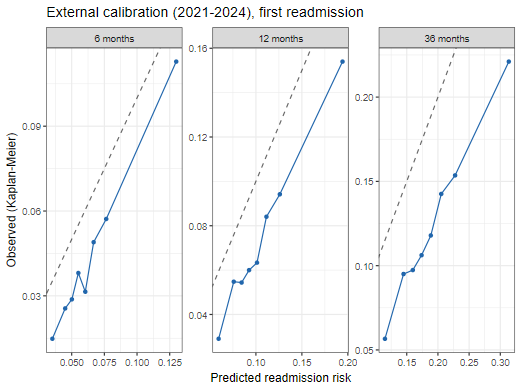

In [11]:
#| label: extval-calibration-curve
#| fig-width: 10
#| fig-height: 3.6
d <- cal_ext$calibration_curves
d$facet <- factor(paste0(d$time_months, " months"), levels = paste0(sort(unique(d$time_months)), " months"))
ggplot2::ggplot(d, ggplot2::aes(mean_predicted, observed)) +
  ggplot2::geom_abline(slope = 1, intercept = 0, linetype = "dashed", alpha = 0.6) +
  ggplot2::geom_line(color = "#2166AC") +
  ggplot2::geom_point(color = "#2166AC", size = 1.4) +
  ggplot2::facet_wrap(~facet, nrow = 1, scales = "free") +
  ggplot2::labs(x = "Predicted readmission risk", y = "Observed (Kaplan-Meier)",
    title = "External calibration (2021-2024), first readmission") +
  ggplot2::theme_bw(base_size = 12)


## Development versus external cohort: standardized mean differences

The development column reproduces the project training-set Table 1 (n = 70,521); the external column is computed from the 2021-2024 cohort. Standardized mean differences quantify covariate shift; |SMD| >= 0.10 is highlighted. Note that very large SMDs for occupational status, domestic violence/sexual abuse and the communal poverty index likely reflect changes in how these fields were recorded or coded in the more recent data rather than pure clinical drift, and should be interpreted with caution.

In [12]:
#| label: extval-smd-table
#| results: asis
#| message: false
smd_tab <- extval_table1_smd(built$nondum)
extval_smd_browsable(smd_tab)


Variable,Level,"Development (n=70,521)","External 2021-2024 (n=26,361)",SMD
Admission motive,Spontaneous consultation,44.9%,11237 (42.6%),0.046
,Health system,31.1%,9335 (35.4%),0.092
,Justice system,9.5%,2718 (10.3%),0.027
,SENDA network / other center,9.3%,2075 (7.9%),0.051
,Other,5.2%,996 (3.8%),0.069
Cohabitation status,Family of origin,37.0%,9608 (36.4%),0.011
,Only with partner and/or children,44.9%,11465 (43.5%),0.028
,Alone,9.5%,3343 (12.7%),0.101
,Others,8.7%,1945 (7.4%),0.049
Educational attainment,Primary or less,26.2%,5853 (22.5%),0.086


## Save

In [13]:
#| label: extval-save
extval_result <- list(
  cohort_flow = built$flow, params = built$params, n_model = nrow(ext_dat),
  eval_times = EVAL_TIMES, cal_times = CAL_TIMES,
  metrics = ev_ext$summary, boot = boot_ext, calibration = cal_ext, smd = smd_tab,
  discrimination_table = disc, calibration_table = calib,
  model = "frozen readmit_1_2 (msm_artifact_2026_06_20.rds); user-specified 26-covariate f_readmit",
  created = as.character(Sys.time()))
out_dir <- file.path(project_root, "data", "20241015_out", "pred26")
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
f_out <- file.path(out_dir, paste0("extval_readmit_", format(Sys.Date(), "%Y_%m_%d"), ".rds"))
saveRDS(extval_result, f_out)
utils::write.csv(disc,  file.path(out_dir, "extval_readmit_discrimination.csv"), row.names = FALSE)
utils::write.csv(calib, file.path(out_dir, "extval_readmit_calibration.csv"),   row.names = FALSE)
utils::write.csv(smd_tab, file.path(out_dir, "extval_readmit_smd_table1.csv"),  row.names = FALSE)
cat("Saved:", f_out, "\n")


Saved: g:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/pred26/extval_readmit_2026_06_29.rds 


## Session info

In [14]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true

message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", getwd()))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

tabla_pkg <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  package,
  loadedversion,
  source
)

tabla_pkg <- tibble::rowid_to_column(tabla_pkg, var = "row_number")

names(tabla_pkg) <- c("Row number", "Package", "Version", "Source")

htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 420px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
      font-size: 70%;
      line-height: 0.75em;
      width: 100%;
    ",
    htmltools::tags$caption(
      style = "
        caption-side: top;
        text-align: left;
        display: block;
        padding: 6px 4px;
        font-size: 120%;
        line-height: 1.2em;
      ",
      htmltools::em("R packages")
    ),
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
        white-space: nowrap;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(tabla_pkg), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                z-index: 2;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(tabla_pkg)), function(i) {
          htmltools::tags$tr(
            lapply(tabla_pkg[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)

R library: C:\Users\andre\AppData\Local/R/win-library/4.4
Date: 2026-06-29 01:04:03.742981
Editor context: g:/My Drive/Alvacast/SISTRAT 2023/cons
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/andre/AppData/Local/Temp/RtmpK4zbg7/file9ed05ea0b82 -V' had status 1


1,backports,1.5.0,CRAN (R 4.4.1)
2,base64enc,0.1-3,CRAN (R 4.4.1)
3,boot,1.3-31,CRAN (R 4.4.1)
4,bpmn,0.1.0,Github (bergant/bpmn@628d3efaa27544c221b2fd7f1895301a63b70c49)
5,broom,1.0.10,CRAN (R 4.4.3)
6,cachem,1.1.0,CRAN (R 4.4.1)
7,caret,7.0-1,CRAN (R 4.4.1)
8,checkmate,2.3.3,CRAN (R 4.4.3)
9,class,7.3-22,CRAN (R 4.4.1)
10,cli,3.6.4,CRAN (R 4.4.1)
11,cluster,2.1.8.1,CRAN (R 4.4.1)
